In [1]:
import numpy as np
import json
import os
import SimpleITK as sitk
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_nifti_files(directory: str):
    nifti_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.nii.gz')):
                nifti_files.append(os.path.join(root, file))

    if len(nifti_files) > 1:
        return sorted(nifti_files,key=lambda x: os.path.basename(x))
    else:
        return nifti_files[0]

/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-026/ses-04/anat/sub-026_ses-04_run-1_T2w.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/derivatives/masks/sub-026/ses-04/anat/sub-026_ses-04_run-1_mask_TE.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-030/ses-04/anat/sub-030_ses-04_run-2_T2w.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/derivatives/masks/sub-030/ses-04/anat/sub-030_ses-04_run-2_mask_TE.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-034/ses-04/anat/sub-034_ses-04_run-3_T2w.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/derivatives/masks/sub-034/ses-04/anat/sub-034_ses-04_run-3_mask_TE.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-04/anat/sub-038_ses-04_run-4_T2w.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/derivatives/masks/sub-038/ses-04/anat/sub-038_ses-04_run-4_mask_TE.nii.gz


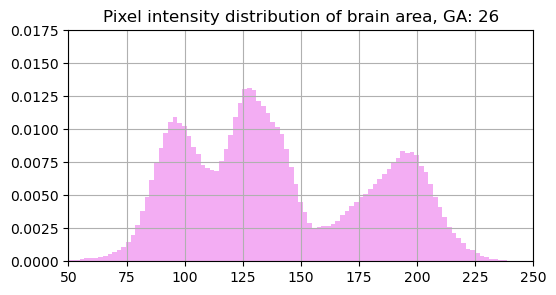

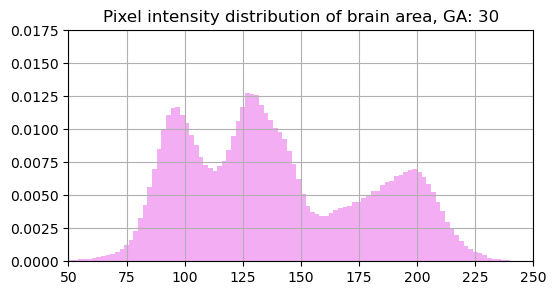

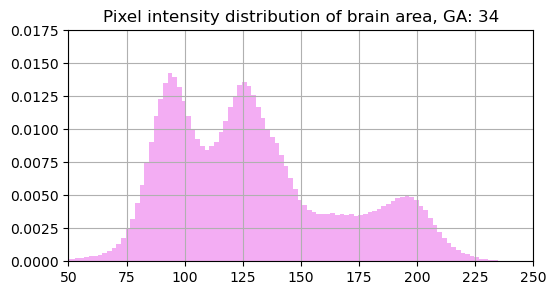

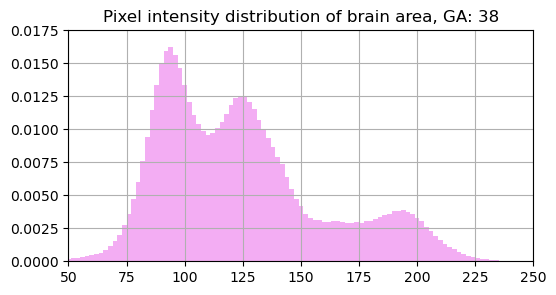

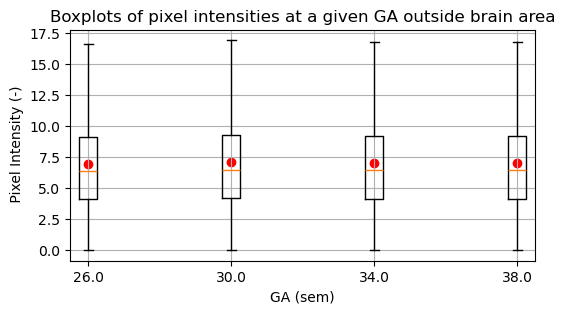

In [33]:
anat_dir = '/home/mroulet/Documents/Data/FaBIAN/sim-006/data/'
anat_imgs = sorted(get_nifti_files(anat_dir))

bin_size= 2
gas = []
data = []
mean_values = []
for anat_img in anat_imgs:

    if ("ses-04" in anat_img) and ("derivatives" not in anat_img):

        # get ga:
        # Sample string
        # Find the index of "sub-" substring
        substring_index = anat_img.find("sub-0")
        ga = float(anat_img[substring_index + len("sub-0"):substring_index + len("sub-0") + 2])
        gas.append(ga)

        # load image
        anat = sitk.GetArrayFromImage(sitk.ReadImage(anat_img))
        mask_img = anat_img.replace("T2w","mask_TE")
        mask_img = mask_img.replace("data","data/derivatives/masks")
        print(anat_img)
        print(mask_img)
        mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_img))
        
        # analyze noise outside brain area (boxplot)
        idx_roi = np.where(mask == 0) # outside brain area
        data.append(anat[idx_roi].flatten())
        mean_values.append(np.mean(anat[idx_roi]))

        # analyze pixel intensities inside brain area (histogram)
        idx_brain = np.where(mask == 1)
        brain_px = anat[idx_brain].flatten()
        plt.figure(figsize=(6,3))
        hist_array1, bins_array1 = np.histogram(brain_px, bins=np.arange(min(brain_px), max(brain_px) + bin_size, bin_size),density=True)
        plt.bar(bins_array1[:-1], hist_array1, width=bin_size, alpha=0.65,color='violet')
        plt.grid("on")
        plt.title(f'Pixel intensity distribution of brain area, GA: {int(ga)}')
        plt.ylim([0,0.0175])
        plt.xlim([50,250])

plt.figure(figsize=(6,3))
plt.boxplot(data, positions = gas, showfliers=False) 
plt.scatter(gas, mean_values,marker='o', color='red') 
plt.title(f'Boxplots of pixel intensities at a given GA outside brain area')
plt.xlabel('GA (sem)')
plt.ylabel(' Pixel Intensity (-)')
plt.grid("on")
plt.show()

In [6]:
anat_imgs

['/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-05/anat/sub-038_ses-05_run-1_T2w.nii.gz',
 '/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-05/anat/sub-038_ses-05_run-2_T2w.nii.gz',
 '/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-05/anat/sub-038_ses-05_run-3_T2w.nii.gz']

/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-05/anat/sub-038_ses-05_run-1_T2w.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/derivatives/masks/sub-038/ses-05/anat/sub-038_ses-05_run-1_mask_TE.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-05/anat/sub-038_ses-05_run-2_T2w.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/derivatives/masks/sub-038/ses-05/anat/sub-038_ses-05_run-2_mask_TE.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-05/anat/sub-038_ses-05_run-3_T2w.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/derivatives/masks/sub-038/ses-05/anat/sub-038_ses-05_run-3_mask_TE.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-05/anat/sub-038_ses-05_run-4_T2w.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/derivatives/masks/sub-038/ses-05/anat/sub-038_ses-05_run-4_mask_TE.nii.gz
/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-05/anat/sub-038_ses-05_run-5_T2w.nii.gz
/ho

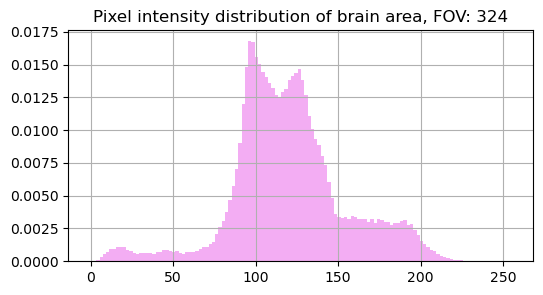

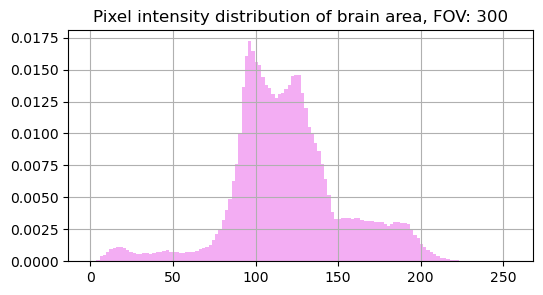

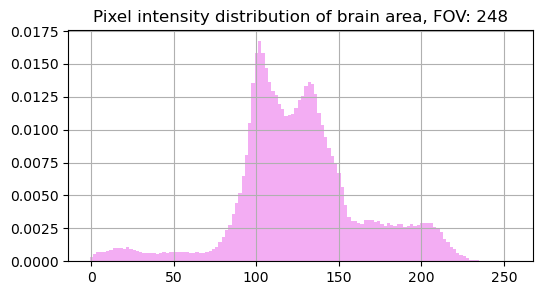

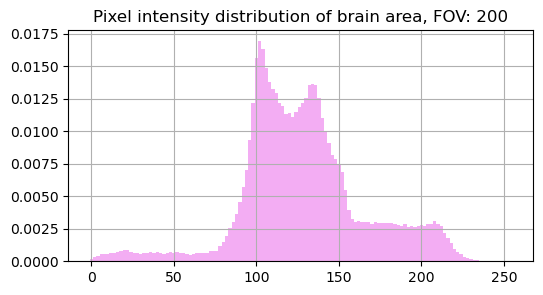

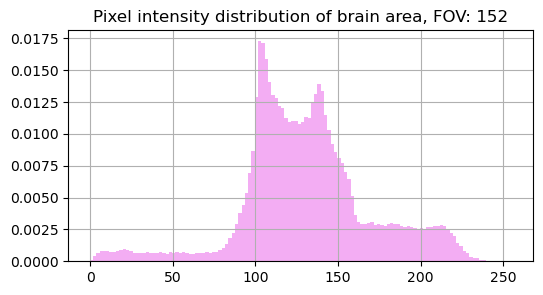

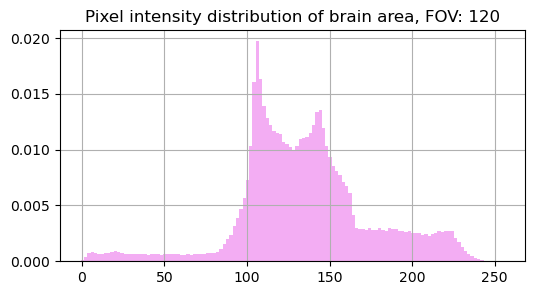

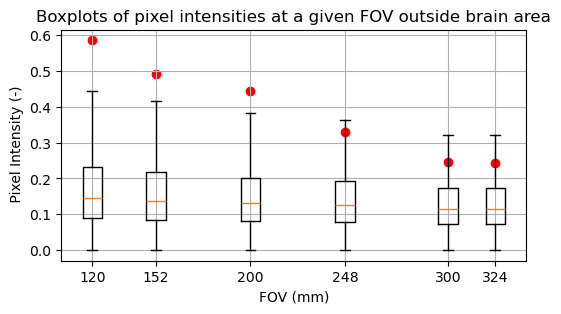

In [16]:
anat_dir = '/home/mroulet/Documents/Data/FaBIAN/sim-006/data/sub-038/ses-05'
anat_imgs = sorted(get_nifti_files(anat_dir))

bin_size= 2
fovs = [324, 300, 248, 200, 152, 120]
data = []
mean_values = []
for anat_img, fov in zip(anat_imgs, fovs):

    if ("ses-05" in anat_img) and ("derivatives" not in anat_img):

        # load image
        anat = sitk.GetArrayFromImage(sitk.ReadImage(anat_img))
        mask_img = anat_img.replace("T2w","mask_TE")
        mask_img = mask_img.replace("data","data/derivatives/masks")
        print(anat_img)
        print(mask_img)
        mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_img))
        
        # analyze noise outside brain area (boxplot)
        idx_roi = np.where(mask == 0) # outside brain area
        data.append(anat[idx_roi].flatten())
        mean_values.append(np.mean(anat[idx_roi]))

        # analyze pixel intensities inside brain area (histogram)
        idx_brain = np.where(mask == 1)
        brain_px = anat[idx_brain].flatten()
        plt.figure(figsize=(6,3))
        hist_array1, bins_array1 = np.histogram(brain_px, bins=np.arange(min(brain_px), max(brain_px) + bin_size, bin_size),density=True)
        plt.bar(bins_array1[:-1], hist_array1, width=bin_size, alpha=0.65,color='violet')
        plt.grid("on")
        plt.title(f'Pixel intensity distribution of brain area, FOV: {fov}')
        #plt.ylim([0,0.0175])
        #plt.xlim([50,250])

plt.figure(figsize=(6,3))
plt.boxplot(data, positions = fovs, showfliers=False, widths=10) 
plt.scatter(fovs, mean_values,marker='o', color='red') 
plt.title(f'Boxplots of pixel intensities at a given FOV outside brain area')
plt.xlabel('FOV (mm)')
plt.ylabel(' Pixel Intensity (-)')
plt.grid("on")
plt.show()